# TERRAPYGE: DEM Preprocessing Notebook (Pure Python) -- BASELINE

**BASELINE ONLY -- not for production.** This notebook uses a naive pit-filling
algorithm and computes slope with degree-spaced pixels (physically incorrect).
Use `02_preprocess_dem.ipynb` (WhiteboxTools) or `phase1_dem_preprocessing.py`
for production DEM conditioning.

This notebook is retained for ablation/comparison purposes only.

## 1. Import Libraries

In [1]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import generic_filter

## 2. Load Raw DEM

In [2]:
# Define paths
dem_path = Path.cwd() / 'data' / 'raw' / 'dem' / 'CebuCity_DEM.tif'
output_dir = Path.cwd() / 'data' / 'processed'
output_dir.mkdir(parents=True, exist_ok=True)

# Load DEM
with rasterio.open(dem_path) as src:
    dem_raw = src.read(1)
    profile = src.profile
    transform = src.transform
    crs = src.crs
    
    # Get pixel size
    pixel_width = transform.a
    pixel_height = -transform.e  # Negative because y decreases going down

print(f"DEM Shape: {dem_raw.shape}")
print(f"CRS: {crs}")
print(f"Pixel size: {pixel_width:.6f} x {pixel_height:.6f} degrees")

DEM Shape: (743, 743)
CRS: EPSG:4326
Pixel size: 0.000269 x 0.000269 degrees


## 3. DEM Conditioning (Simple Pit Filling)

In [3]:
def fill_pits_simple(dem, iterations=1):
    """
    Simple pit filling using local minimum filter.
    """
    dem_filled = dem.copy()
    
    for _ in range(iterations):
        kernel = np.ones((3, 3))
        local_min = generic_filter(dem_filled, np.min, footprint=kernel)
        dem_filled = np.maximum(dem_filled, local_min)
    
    return dem_filled

# Apply simple pit filling
print("Filling pits (simple method)...")
dem_conditioned = fill_pits_simple(dem_raw, iterations=2)
print("Pit filling complete.")

Filling pits (simple method)...
Pit filling complete.


## 4. Calculate Slope (Pure Python)

In [4]:
def calculate_slope(dem, pixel_width, pixel_height):
    """
    Calculate slope from DEM using finite differences.
    Returns slope in degrees.
    """
    # Calculate gradient using numpy
    dy, dx = np.gradient(dem, pixel_height, pixel_width)
    
    # Calculate slope in radians
    slope_rad = np.arctan(np.sqrt(dx**2 + dy**2))
    
    # Convert to degrees
    slope_deg = np.degrees(slope_rad)
    
    return slope_deg

print("Calculating slope...")
slope = calculate_slope(dem_conditioned, pixel_width, pixel_height)
print(f"Slope range: {slope.min():.2f}° - {slope.max():.2f}°")

Calculating slope...
Slope range: 0.00° - 90.00°


## 5. Calculate Aspect (Pure Python)

In [5]:
def calculate_aspect(dem, pixel_width, pixel_height):
    """
    Calculate aspect from DEM using finite differences.
    Returns aspect in degrees (0-360, where 0=North, 90=East, 180=South, 270=West).
    """
    # Calculate gradient
    dy, dx = np.gradient(dem, pixel_height, pixel_width)
    
    # Calculate aspect in radians
    aspect_rad = np.arctan2(-dy, dx)
    
    # Convert to degrees
    aspect_deg = np.degrees(aspect_rad)
    
    # Convert from -180-180 to 0-360
    aspect_deg = (aspect_deg + 360) % 360
    
    return aspect_deg

print("Calculating aspect...")
aspect = calculate_aspect(dem_conditioned, pixel_width, pixel_height)
print(f"Aspect range: {aspect.min():.2f}° - {aspect.max():.2f}°")

Calculating aspect...
Aspect range: 0.00° - 359.17°


## 6. Visualize Results

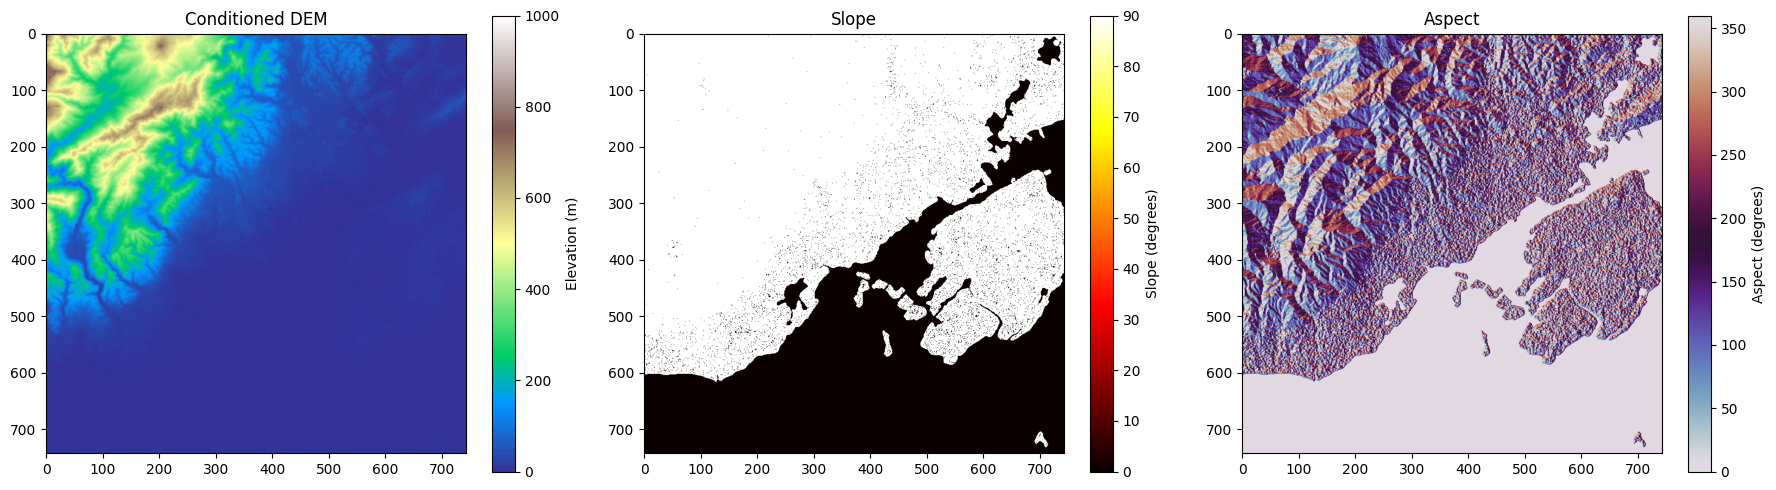

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# DEM
im1 = axes[0].imshow(dem_conditioned, cmap='terrain', vmin=0, vmax=1000)
plt.colorbar(im1, ax=axes[0], label='Elevation (m)')
axes[0].set_title('Conditioned DEM')

# Slope
im2 = axes[1].imshow(slope, cmap='hot', vmin=0, vmax=90)
plt.colorbar(im2, ax=axes[1], label='Slope (degrees)')
axes[1].set_title('Slope')

# Aspect
im3 = axes[2].imshow(aspect, cmap='twilight', vmin=0, vmax=360)
plt.colorbar(im3, ax=axes[2], label='Aspect (degrees)')
axes[2].set_title('Aspect')

plt.tight_layout()
plt.show()

## 7. Save Processed Data

In [7]:
# Update profile for processed data
profile.update(dtype=rasterio.float32, nodata=-9999)

# Save Conditioned DEM
dem_path_out = output_dir / 'CebuCity_DEM_conditioned.tif'
with rasterio.open(dem_path_out, 'w', **profile) as dst:
    dst.write(dem_conditioned.astype(rasterio.float32), 1)

# Save Slope
slope_path_out = output_dir / 'CebuCity_Slope_conditioned.tif'
with rasterio.open(slope_path_out, 'w', **profile) as dst:
    dst.write(slope.astype(rasterio.float32), 1)

# Save Aspect
aspect_path_out = output_dir / 'CebuCity_Aspect_conditioned.tif'
with rasterio.open(aspect_path_out, 'w', **profile) as dst:
    dst.write(aspect.astype(rasterio.float32), 1)

print(f"Saved conditioned DEM to: {dem_path_out}")
print(f"Saved slope to: {slope_path_out}")
print(f"Saved aspect to: {aspect_path_out}")

Saved conditioned DEM to: D:\TERRAPYGE\data\processed\CebuCity_DEM_conditioned.tif
Saved slope to: D:\TERRAPYGE\data\processed\CebuCity_Slope_conditioned.tif
Saved aspect to: D:\TERRAPYGE\data\processed\CebuCity_Aspect_conditioned.tif


## 8. Next Steps

1. **Notebook 03: Slope Unit Extraction**
   - Use the conditioned DEM to extract slope units.
   - Run `03_slope_units_extraction_fixed.ipynb` next.